In [38]:
from notebooks_function import *

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pypsa
import warnings
import country_converter as coco

cc = coco.CountryConverter()


def get_time_series(n, df, country, date_time, title):

    df = df / 1e3

    year = str(n.snapshots.year[0])

    start_time = f'{year}-' + date_time[0]
    end_time = f'{year}-' + date_time[1]
    
    df_country = df[df.index.get_level_values("country") == country]
    df_country = df_country.groupby("carrier").sum()
    
    df_load = n.loads_t.p_set[f"GO Demand {country} New"]  / 1e3
    df_buffer = n.generators_t.p[f"GO Buffer {country} New charger"] - n.generators_t.p[f"GO Buffer {country} New discharger"]  / 1e3
    df_load_balance = df_buffer
    df_country = df_country[df_country.index != "GoO"]
    
    df_pos = df_country.clip(lower=0)
    df_neg = df_country.clip(upper=0)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    df_pos.loc[:,start_time:end_time].T.plot(
        kind="area",
        ax=ax,
        color=[n.carriers.color[c] for c in df_pos.index]
    )
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore", 
            message="Attempting to set identical low and high ylims"
        )
        
        df_neg.loc[:,start_time:end_time].T.plot(
            kind="area",
            ax=ax,
            color=[n.carriers.color[c] for c in df_neg.index],
            legend=False
        )
    
    # Plot load demand (overlaid)
    df_load.loc[start_time:end_time].plot(
        ax=ax,
        color="black",
        linewidth=2,
        style='--',
        alpha=0.8,
    )
    
    # ---- Legend Formatting ----
    handles, labels = ax.get_legend_handles_labels()
    handles, labels = handles[::-1], labels[::-1]  # Reverse for nicer order
    
    # Remove duplicates while preserving order (reversed)
    seen = set()
    unique = [(h, l) for h, l in zip(handles, labels) if l not in seen and not seen.add(l)]
    
    # Unzip the filtered handles and labels
    handles, labels = zip(*unique)
    
    # Replace technical carrier names with nice names if available
    labels = [
        n.carriers.nice_name.get(label, label) #.title()
        for label in labels
    ]
    
    ax.legend(
        handles,
        labels,
        title="Carrier",
        bbox_to_anchor=(1.0, 0.85),
        loc='upper left'
    )
    
    ymax = df_pos.sum().max()
    ymin = df_neg.sum().min()
    
    delta = abs(ymax) * 0.1
    ymin -= delta
    ymax += delta
    
    ax.set_ylim(ymin, ymax)
    ax.set_ylabel("Generation [GW]")
    ax.grid()
    
    result = pd.concat([df_load, df_country.sum()], axis=1).min(axis=1)
    hourly_matching = round((n.snapshot_weightings.objective @ result) / (n.snapshot_weightings.objective @ df_load) * 100, 2)
    country_name = cc.convert(names=country, to='name_short')
    ax.set_title(title + f": {hourly_matching}% Hourly Matching")
    
    fig.tight_layout()

    return fig


# 1 - Retrieve networks

In [34]:
years = [2025, 2030, 2035, 2040]
# Main
scenarios = ["baseline",
             "energy-match-50",
             "hourly-match-50-90",
             "hourly-match-50-95",
             "hourly-match-50-98",
             "hourly-match-50-99",
             ]


# Sensitivities NOTE: change the folder directory for Sensitivites
# scenarios = ["baseline", # Main
#              "hourly-match-noadd-10-99",
#              "hourly-match-noadd-50-99",
#              "hourly-match-noadd-90-99",
#              "hourly-match-50-99", # Main
#              "hourly-match-no-clean-firm-50-99",
#              "hourly-match-no-LDES-50-99",
#             ]


# Build MultiIndex
index = pd.MultiIndex.from_product(
    [years, scenarios],
    names=["year", "scenario"]
)

# Create empty DataFrame
df_networks = pd.DataFrame(index=index, columns=["network"])

# Fill it
for year, sc in index:
    try:
        n = pypsa.Network(f"../results/{sc}/networks/base_s_39___{year}.nc")
    except:
        print(f"{sc}-{year} not availabe")
        continue
    n = prepare_network(n)
    n = rename_year(n, year)
    n.name = f"{sc}-{year}"
    df_networks.loc[(year, sc), "network"] = n

    m = strip_network_GoO(n)
    m.name = "GoO-" + m.name
    df_networks.loc[(year, sc), "GoO"] = m

df_networks = df_networks.dropna()

INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current: 1.0.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.0.4 available! (Current:

-------------------------------------Analyzing Albania


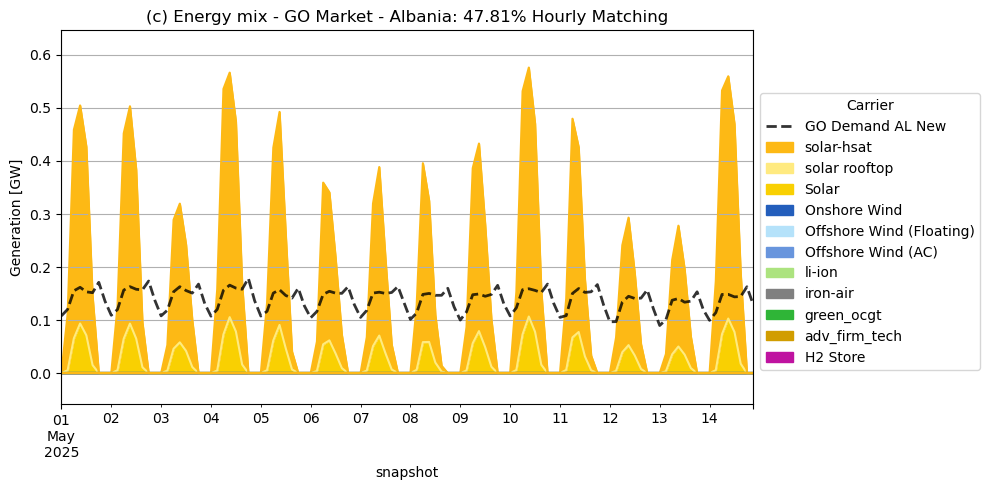

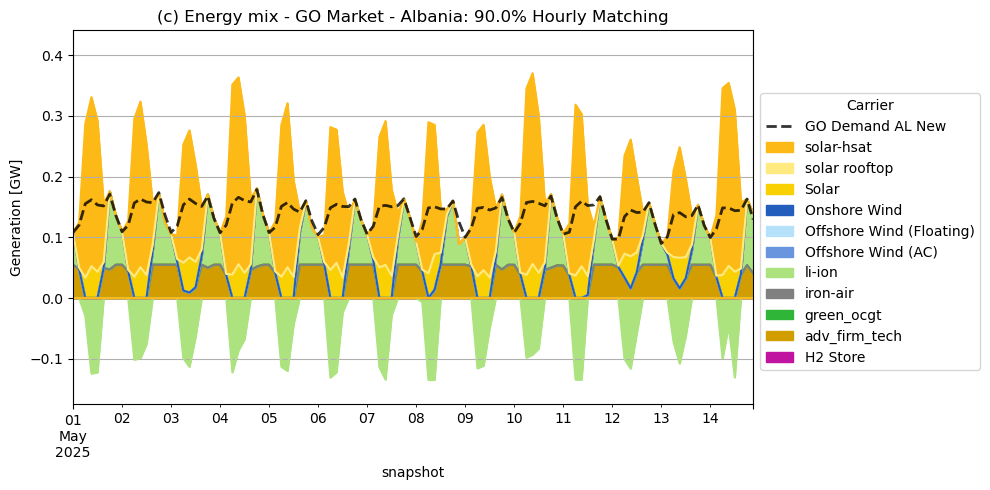

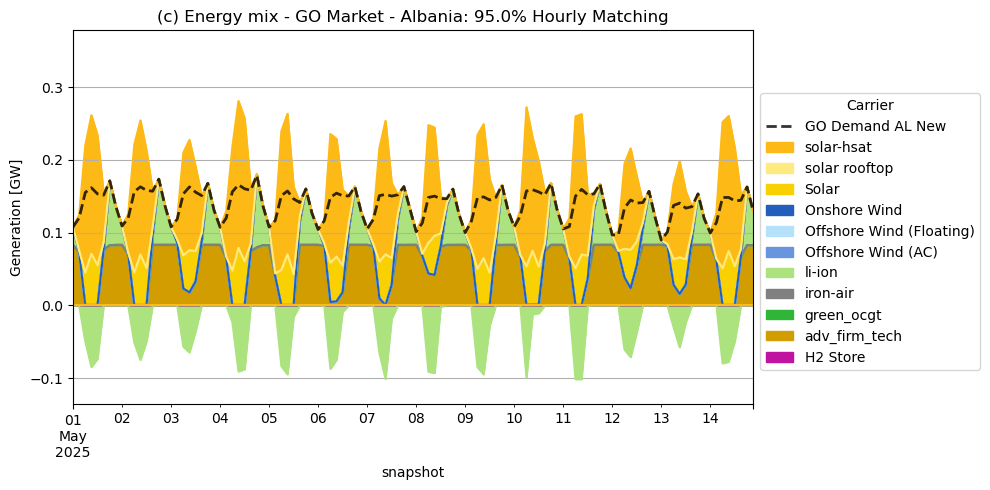

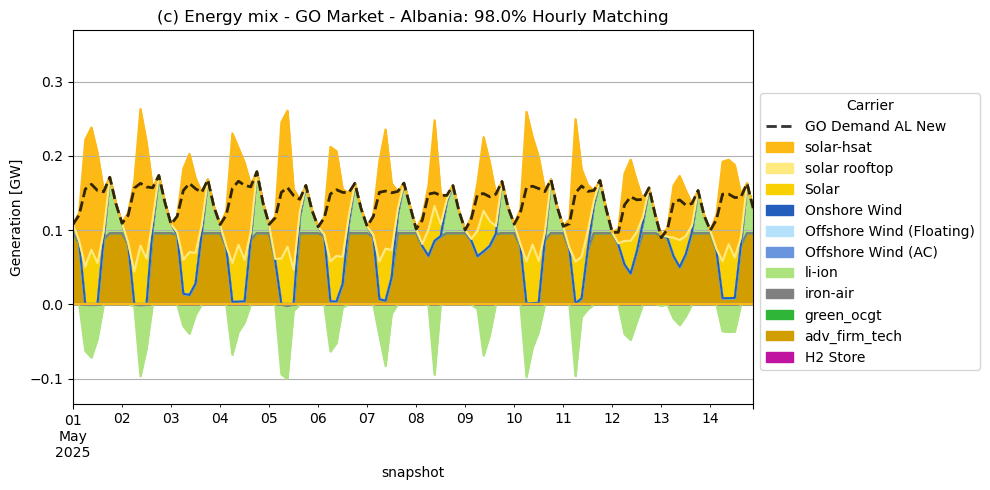

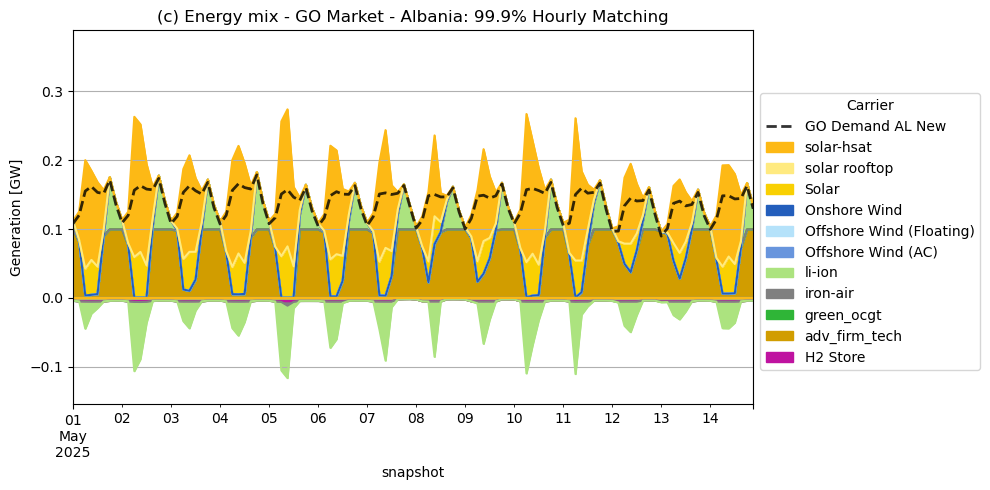

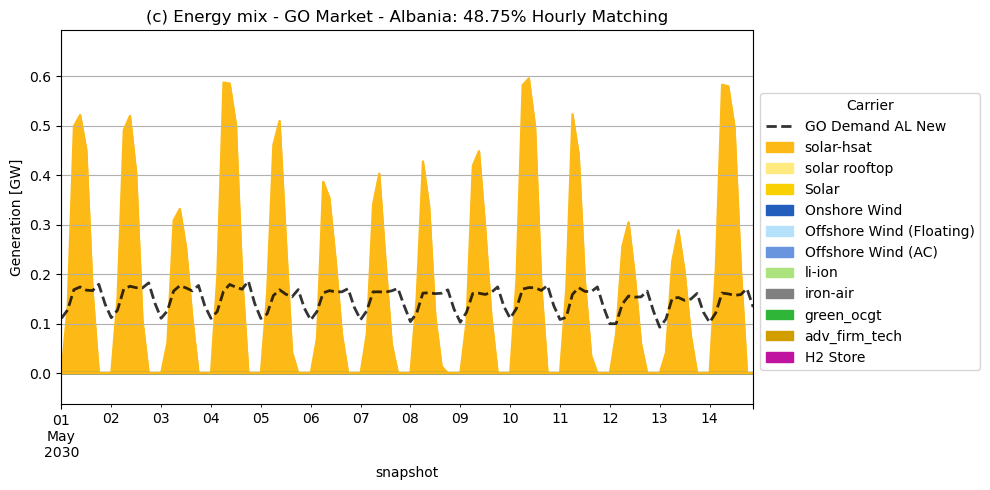

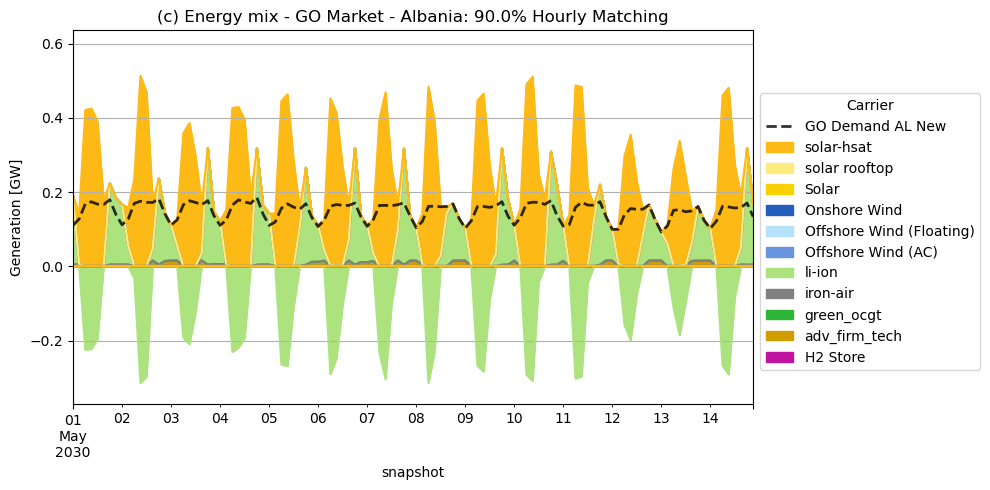

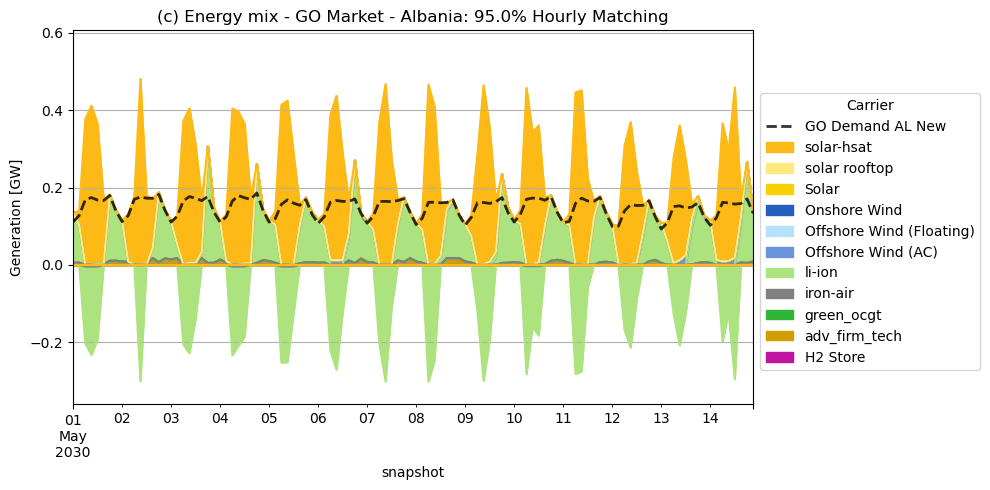

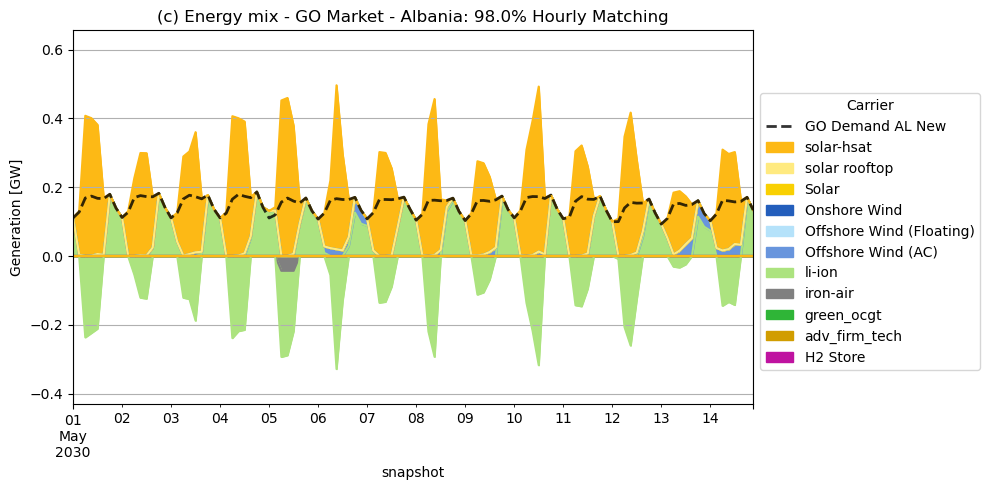

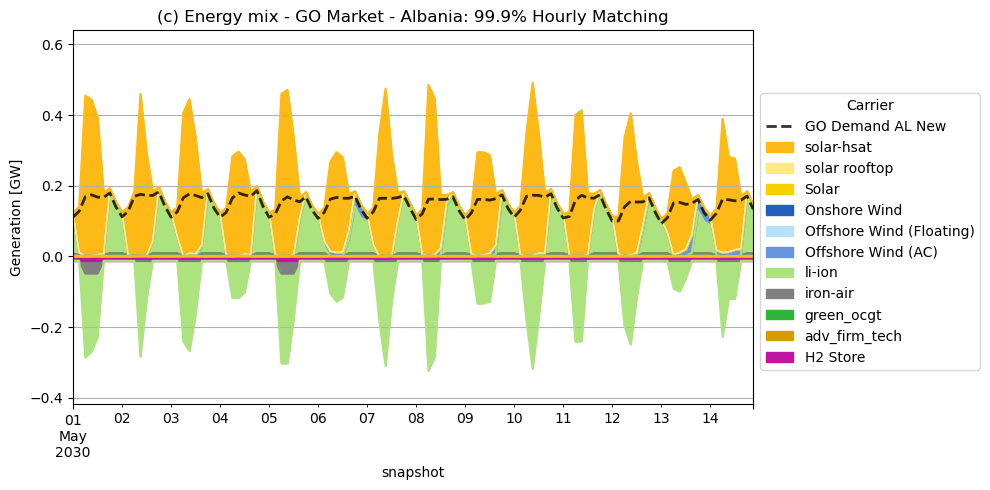

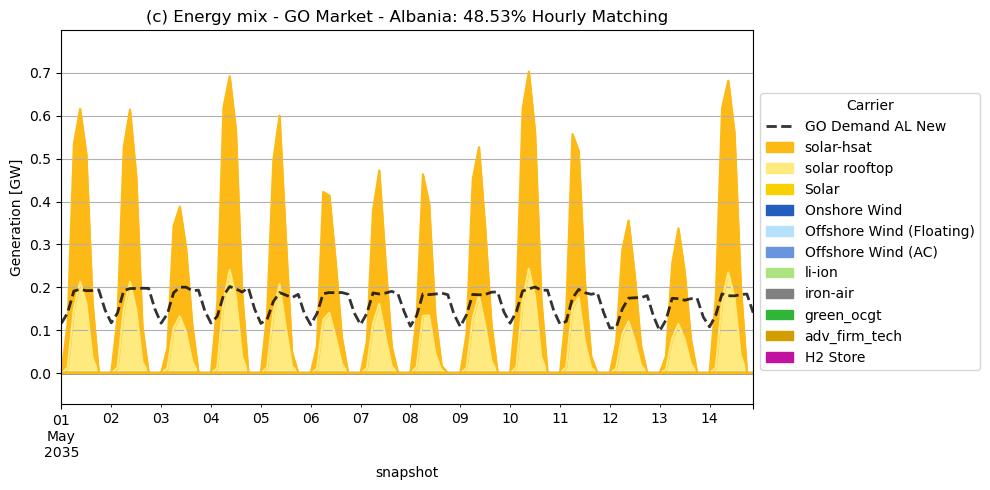

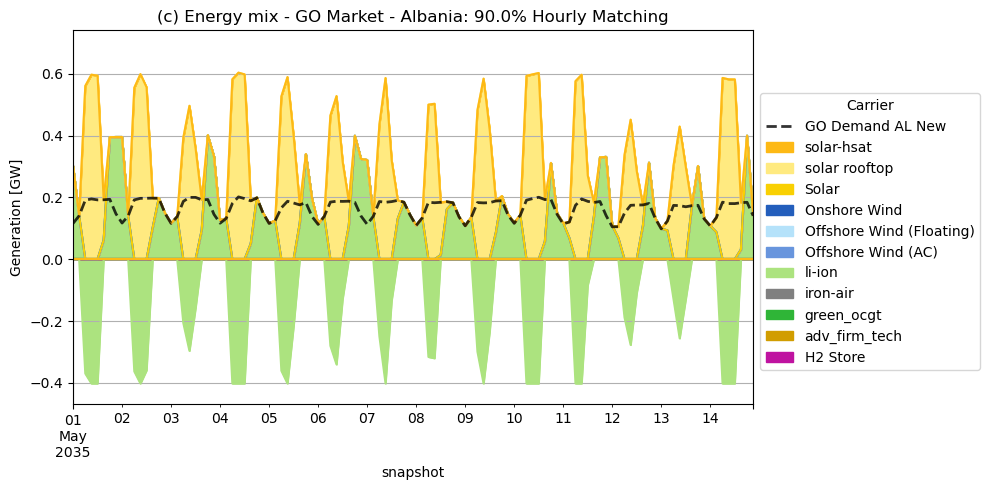

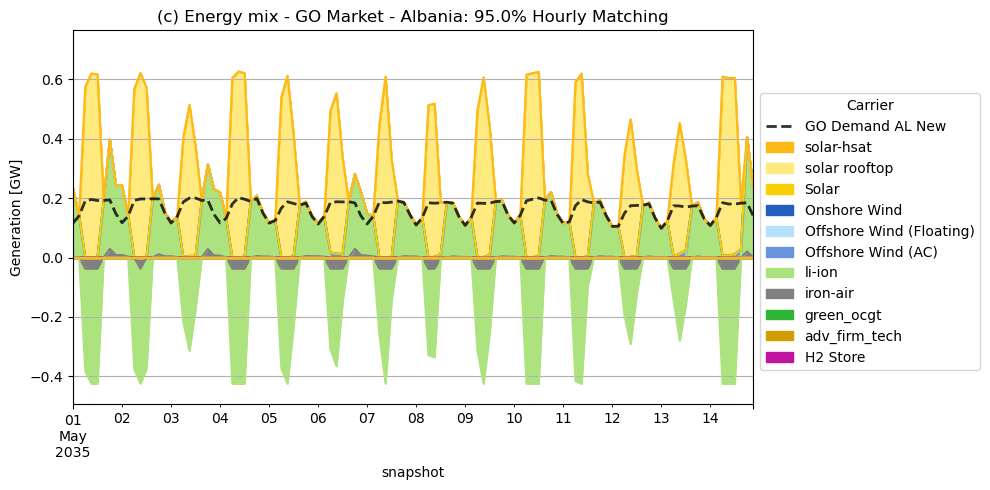

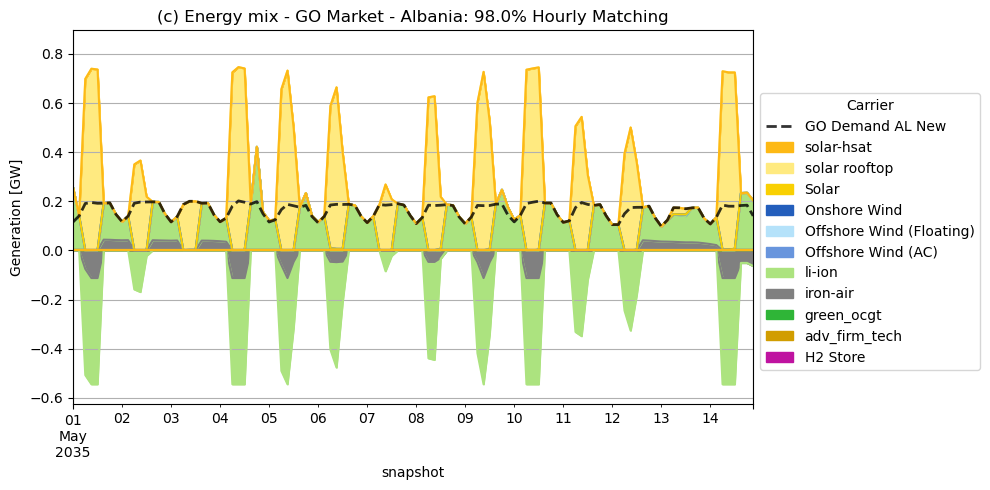

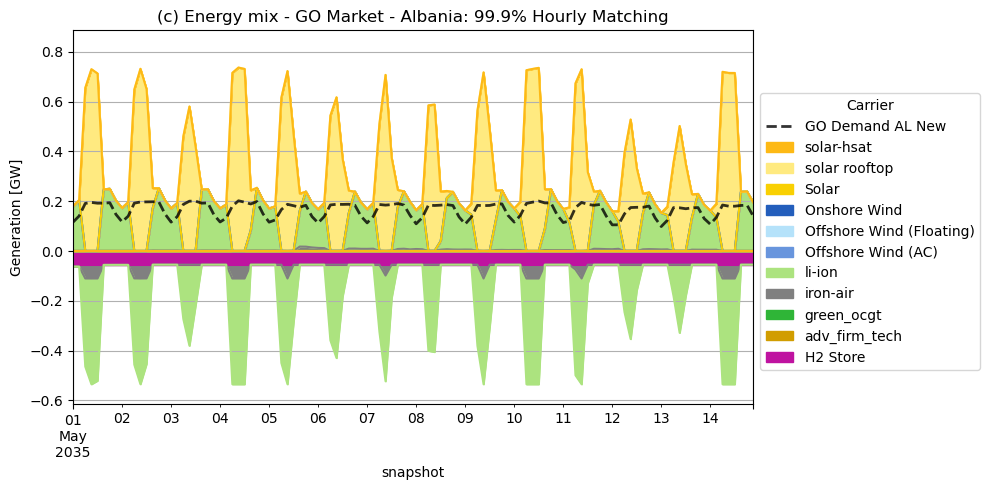

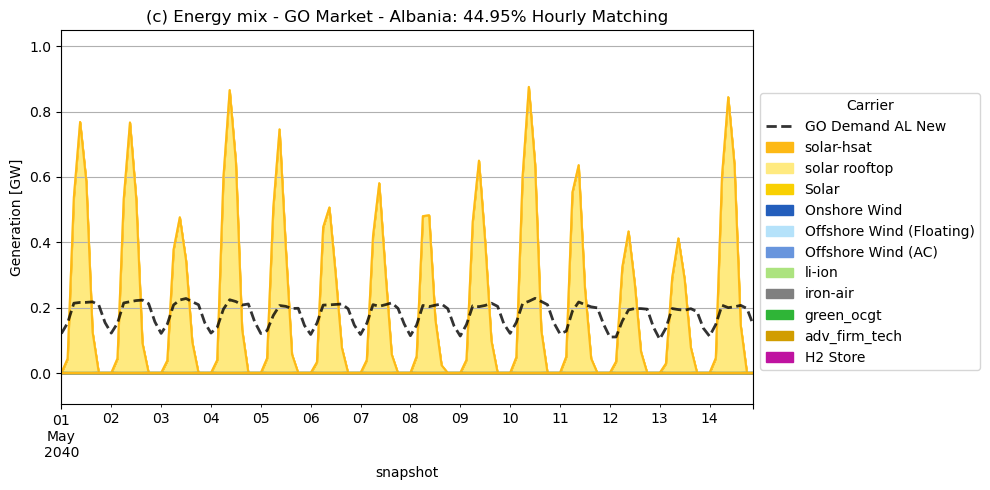

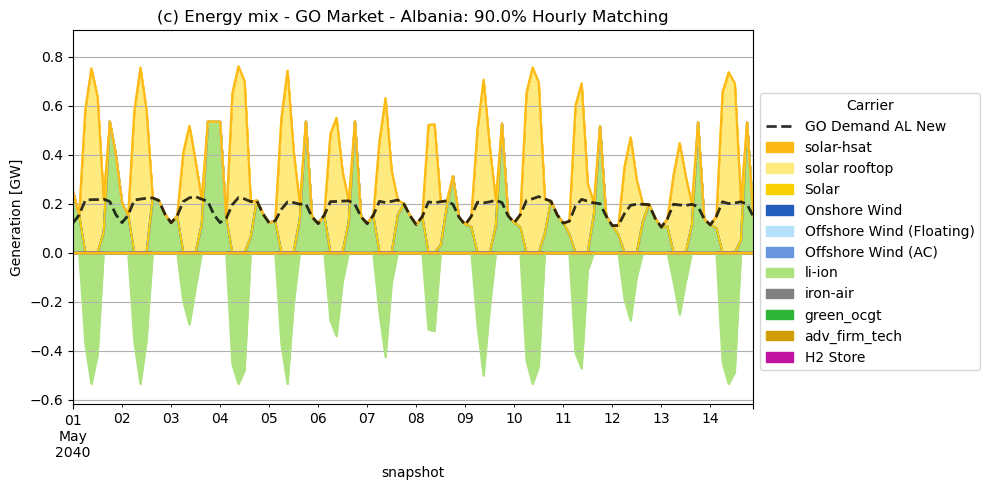

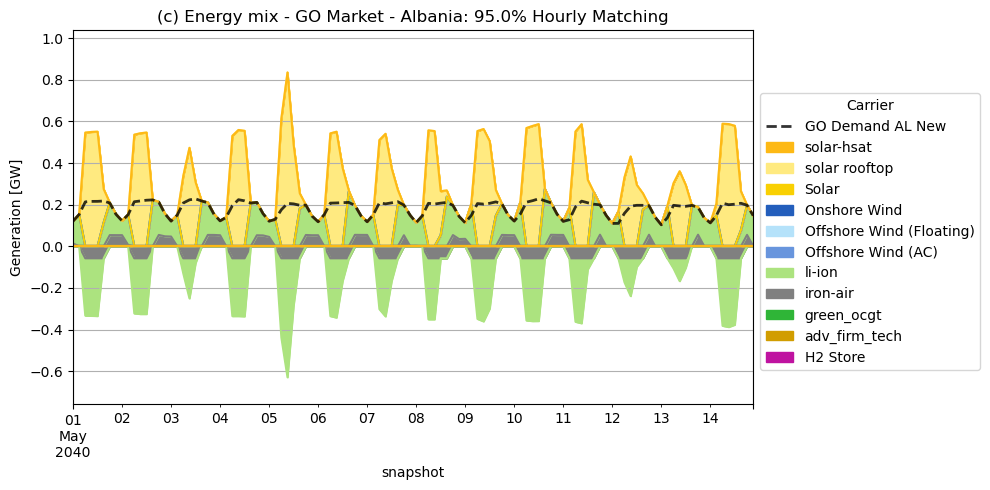

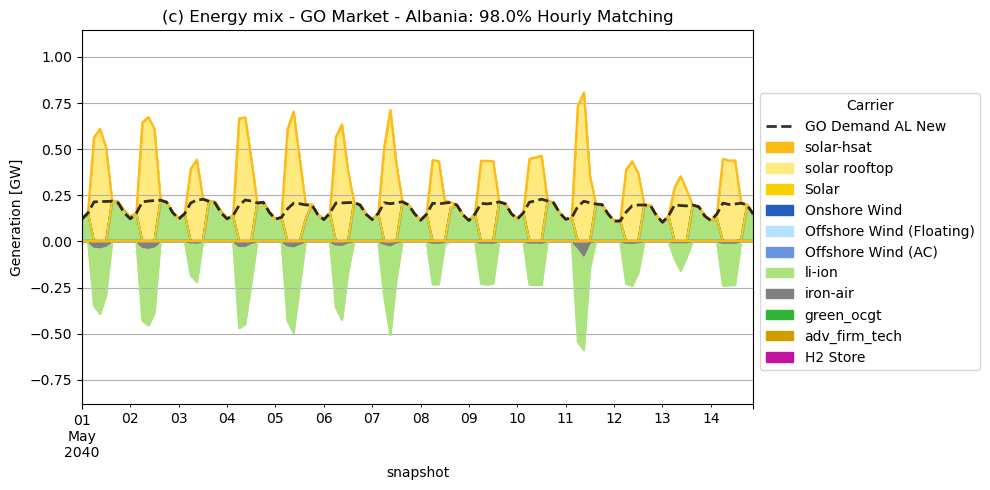

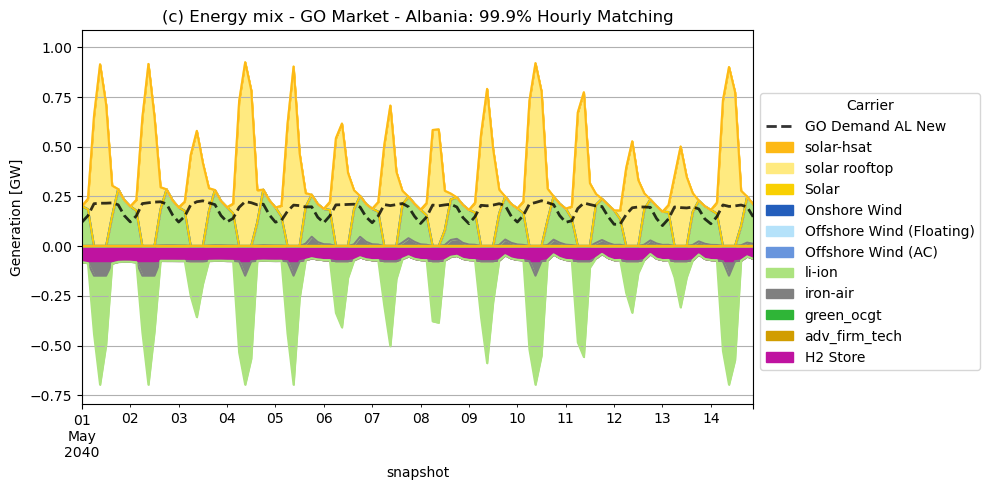

In [41]:
date_time = ('05-01','05-14')
save_fig = False

df_GoO, _ = get_stats_all(df_networks["GoO"], "energy_balance", groupby=["country","carrier"], aggregate_time=False)
countries = list(set(df_networks.iloc[0,0].buses.country.unique()) - {""})

for country in sorted(countries):
    
    cc_name = cc.convert(country, to="short_name")
    fig_path = f"figures/GoO_time_series/country/"
    print(f"-------------------------------------Analyzing {cc_name}")
    
    for year, scenario in df_networks.index:
        if scenario == "baseline":
            continue

        title_fig = f"GO Time Series - {sc} - {cc_name}"

        df_balance = df_GoO[(year, scenario)]
        df_balance = clean_virtual_names(df_balance)

        m = df_networks.loc[(year,scenario),"GoO"]
        fig = get_time_series(
            m, 
            df_balance, 
            country, 
            date_time, 
            title = f"GO Time Series - {cc_name}"
        )

        if save_fig:
            os.makedirs(fig_path, exist_ok=True)
            fig.savefig(f"{fig_path}/{cc_name}/{title_fig}.png", dpi=300, bbox_inches="tight")
